# Sampling Variability and Standard Error

In real-world data analysis, metrics such as conversion rates or model accuracy
are **estimates**, not fixed values.

If we repeat the same experiment multiple times using different samples,
the results will naturally vary.

This notebook demonstrates:

• how sample estimates fluctuate  
• how sampling error behaves  
• how the **Standard Error** quantifies this uncertainty

## Experiment Setup

We simulate a population where the true conversion rate is **12%**.

From this population we repeatedly draw random samples
and estimate the conversion rate in each sample.

By repeating this process many times we can observe the
**sampling distribution of the estimator**.

## Simulating Repeated Sampling

We perform the following steps:

1. Generate a large population with a known conversion rate
2. Draw many random samples from that population
3. Compute the conversion rate estimate for each sample
4. Measure the sampling error (difference between estimate and true rate)

In [21]:
#importing libraries
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.utils import set_seed
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
set_seed(42)
#Generate a large population with a known conversion rate
population_size = 100000
true_rate = 0.12
population = np.random.binomial(1,true_rate,population_size)

In [22]:
#Sampling parameter 
sample_size = 200
num_samples = 1000

sample_means = []
sample_errors = []

for _ in range(num_samples):
    sample = np.random.choice(population, sample_size, replace=False)
    estimate = np.mean(sample)

    sample_means.append(estimate)
    sample_errors.append(estimate - true_rate)

sample_means = np.array(sample_means)
sample_errors = np.array(sample_errors)

In [23]:
#Theoretical Standard Error
theoretical_se = np.sqrt(true_rate * (1 - true_rate) / sample_size)

True conversion rate: 0.120
Average sample estimate: 0.118
Average sampling error: -0.00150
Simulated Standard Error: 0.02222
Theoretical Standard Error: 0.02298


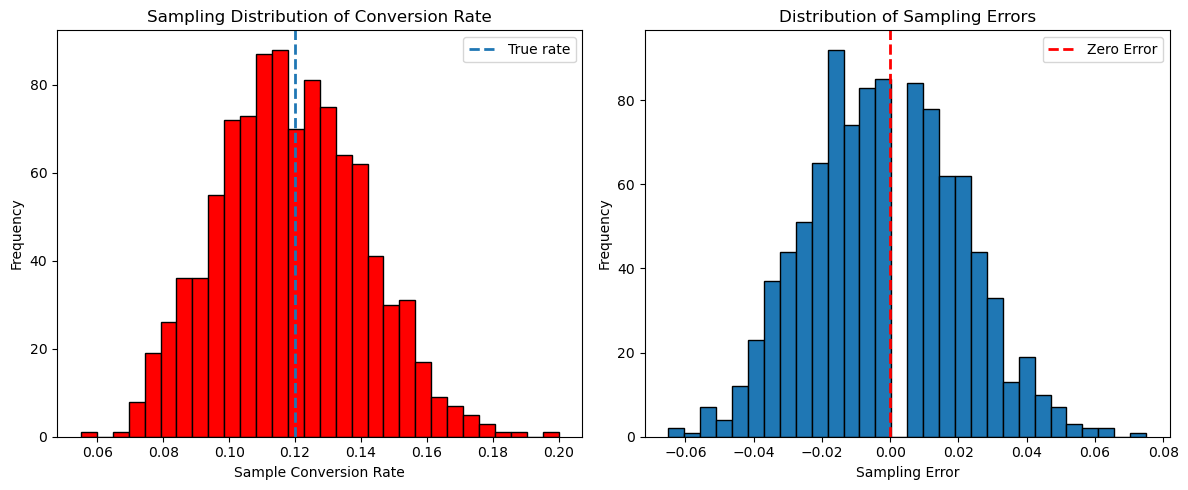

In [27]:
print(f"True conversion rate: {true_rate:.3f}")
print(f"Average sample estimate: {samples_mean.mean():.3f}")
print(f"Average sampling error: {samples_error.mean():.5f}")
print(f"Simulated Standard Error: {sample_errors.std():.5f}")
print(f"Theoretical Standard Error: {theoretical_se:.5f}")
## plotting ##
#Sampling Distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(samples_mean,color="red", bins=30, edgecolor='black')
plt.axvline(true_rate, linestyle='dashed', linewidth=2, label="True rate")
plt.xlabel("Sample Conversion Rate")
plt.ylabel("Frequency")
plt.title("Sampling Distribution of Conversion Rate")
plt.legend()

#Sampling Error Distibution
plt.subplot(1,2,2)
plt.hist(sample_errors, bins=30, edgecolor="black")
plt.axvline(0,color="red",linestyle="dashed",linewidth = 2 ,label = "Zero Error")
plt.xlabel("Sampling Error")
plt.ylabel("Frequency")
plt.title("Distribution of Sampling Errors")
plt.legend()

plt.tight_layout()
plt.show()

## Results

The first plot shows the **sampling distribution of the estimated conversion rate**.

Even though the true rate is fixed, the estimates vary across samples
due to randomness in the sampling process.

The second plot shows the **distribution of sampling errors**.

Most errors are close to zero, but some estimates can deviate
significantly from the true value.

This variability is summarized by the **Standard Error**.

## Key Insight

Metrics in data science are rarely exact values.

They are **estimates influenced by sampling variability**.

Understanding this variability helps when:

• interpreting model performance  
• evaluating experiment results  
• designing reliable A/B tests  

“This is why concepts such as standard error and the Central Limit Theorem are fundamental in statistical reasoning for data science.”